# 03 Service-time diagnosis and adjusted-speed maps

This notebook reads `segment_model_table.csv.gz` from the aligned variable stage. It does not read the old filtered CSV and it does not re-snap points. The map uses `path_edge_keys` generated from the same GraphML used in the variable stage.


In [4]:
from pathlib import Path
import json

BASE_DIR = Path.cwd()
PIPELINE_ROOT = BASE_DIR / "outputs_pipeline_aligned"
MANIFEST_PATH = PIPELINE_ROOT / "pipeline_manifest.json"
PIPELINE_MANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8")) if MANIFEST_PATH.exists() else {}

OUTPUT_ROOT = Path(PIPELINE_MANIFEST.get("diagnostic_map_root", PIPELINE_ROOT / "03_diagnostics_maps"))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

GRAPHML_PATH = Path(PIPELINE_MANIFEST.get("graph_file", PIPELINE_ROOT / "00_graph" / "baoding_aligned.graphml"))
SEGMENT_MODEL_CSV_GZ = Path(PIPELINE_MANIFEST.get("segment_model_csv_gz", PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv.gz"))
SEGMENT_MODEL_CSV = SEGMENT_MODEL_CSV_GZ.with_suffix("") if str(SEGMENT_MODEL_CSV_GZ).endswith(".gz") else SEGMENT_MODEL_CSV_GZ

if not GRAPHML_PATH.exists():
    raise FileNotFoundError("Missing aligned GraphML: %s" % GRAPHML_PATH)
if not SEGMENT_MODEL_CSV_GZ.exists():
    raise FileNotFoundError("Missing aligned segment model: %s" % SEGMENT_MODEL_CSV_GZ)

print("GRAPHML_PATH:", GRAPHML_PATH)
print("SEGMENT_MODEL_CSV_GZ:", SEGMENT_MODEL_CSV_GZ)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


GRAPHML_PATH: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml
SEGMENT_MODEL_CSV_GZ: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz
OUTPUT_ROOT: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps


## 1. Service-time deduction diagnosis


Reading segment model table: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz

Service-time deduction diagnosis, aligned with 1_variables_modified
Source: Rows with nonempty path_edge_keys
Rows after filters: 451887
Main deduction tested: 180 seconds
Distance column: final_distance_m
Duration column: duration
Segment model table: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz

Action pair distribution after filters:
pair_type
FETCH -> DELIVER      186403
DELIVER -> DELIVER     92864
GRAB -> FETCH          72427
DELIVER -> FETCH       27138
FETCH -> FETCH         25707
FETCH -> GRAB          20661
GRAB -> DELIVER        15773
DELIVER -> GRAB        10914

Deduction grid summary:


,deduction_sec,n_total,n_valid,invalid_n,invalid_pct,mean_speed,median_speed,p75_speed,p90_speed,p95_speed,p99_speed,share_speed_gt_high_pct,share_speed_lt_low_pct,median_adjusted_duration_sec
0,0,451887,451887,0,0.000,11.534,11.086,14.589,17.962,20.138,24.416,0.000,0.0,486.0
1,60,451887,451887,0,0.000,13.192,12.636,16.622,20.604,23.236,28.538,0.002,0.0,426.0
2,120,451887,451887,0,0.000,15.520,14.692,19.492,24.550,27.956,35.259,0.009,0.0,366.0
3,180,451887,451887,0,0.000,19.130,17.596,23.987,31.322,36.530,48.030,0.160,0.0,306.0
4,240,451887,451887,0,0.000,26.035,22.091,32.369,46.589,57.731,82.150,4.325,0.0,246.0
5,300,451887,448897,2990,0.662,68.197,29.518,54.019,120.746,222.306,792.411,22.134,0.0,188.0
6,360,451887,364351,87536,19.371,83.563,33.841,64.812,150.181,280.372,1006.393,27.179,0.0,180.0
7,420,451887,290958,160929,35.613,96.457,38.126,75.857,177.692,335.068,1167.833,31.955,0.0,175.0
8,480,451887,230540,221347,48.983,112.841,42.192,87.244,211.793,401.561,1393.387,36.128,0.0,174.0
9,540,451887,180979,270908,59.950,126.535,45.940,96.450,238.871,456.109,1591.672,39.377,0.0,174.0


Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/diagnostics/service_time_deduction/service_time_deduction_grid_summary.csv

----------------------------------------------------------------------
Main deduction detailed summary
----------------------------------------------------------------------
Total rows: 451887
Valid adjusted-speed rows: 451887
Invalid adjusted-speed rows: 0, 0.00%

Adjusted speed summary:
Mean speed: 19.13 km/h
Median speed: 17.60 km/h
P90 speed: 31.32 km/h
P95 speed: 36.53 km/h
P99 speed: 48.03 km/h
Max speed: 127.70 km/h
High adjusted speed rows (> 60.0 km/h): 725 rows, 0.16%
Very low adjusted speed rows (< 0.5 km/h): 0 rows, 0.00%

Pair-level adjusted-speed summary:


,pair_type,Count,AdjSpeed_Mean,AdjSpeed_Median,AdjSpeed_Max,AdjTime_Mean,AdjTime_Median,RawTime_Mean,RawTime_Median,Dist_Mean,Dist_Median
0,FETCH -> DELIVER,186403,19.95,18.62,83.68,491.23,404.0,671.23,584.0,2380.11,2129.85
1,DELIVER -> DELIVER,92864,18.30,16.77,75.05,320.61,275.0,500.61,455.0,1450.37,1327.84
2,GRAB -> FETCH,72427,16.49,13.99,116.01,341.16,278.0,521.16,458.0,1329.64,1092.30
3,DELIVER -> FETCH,27138,18.28,16.48,73.64,287.36,237.0,467.36,417.0,1274.37,1120.52
4,FETCH -> FETCH,25707,19.31,17.62,78.99,258.05,212.0,438.05,392.0,1212.06,1086.08
5,FETCH -> GRAB,20661,24.24,22.27,105.16,355.92,276.0,535.92,456.0,2015.10,1835.17
6,GRAB -> DELIVER,15773,19.22,17.44,109.99,266.00,226.0,446.00,406.0,1264.20,1168.11
7,DELIVER -> GRAB,10914,21.53,19.55,127.70,267.53,222.0,447.53,402.0,1401.24,1287.94


Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/diagnostics/service_time_deduction/service_time_deduction_pair_summary_180s.csv

Drawing service-time deduction diagnosis figure...


/var/folders/jq/7jf33_vn5bjcn7nj1737c9gh0000gn/T/ipykernel_85815/2560830631.py:587: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/diagnostics/service_time_deduction/service_time_deduction_diagnosis_180s.png


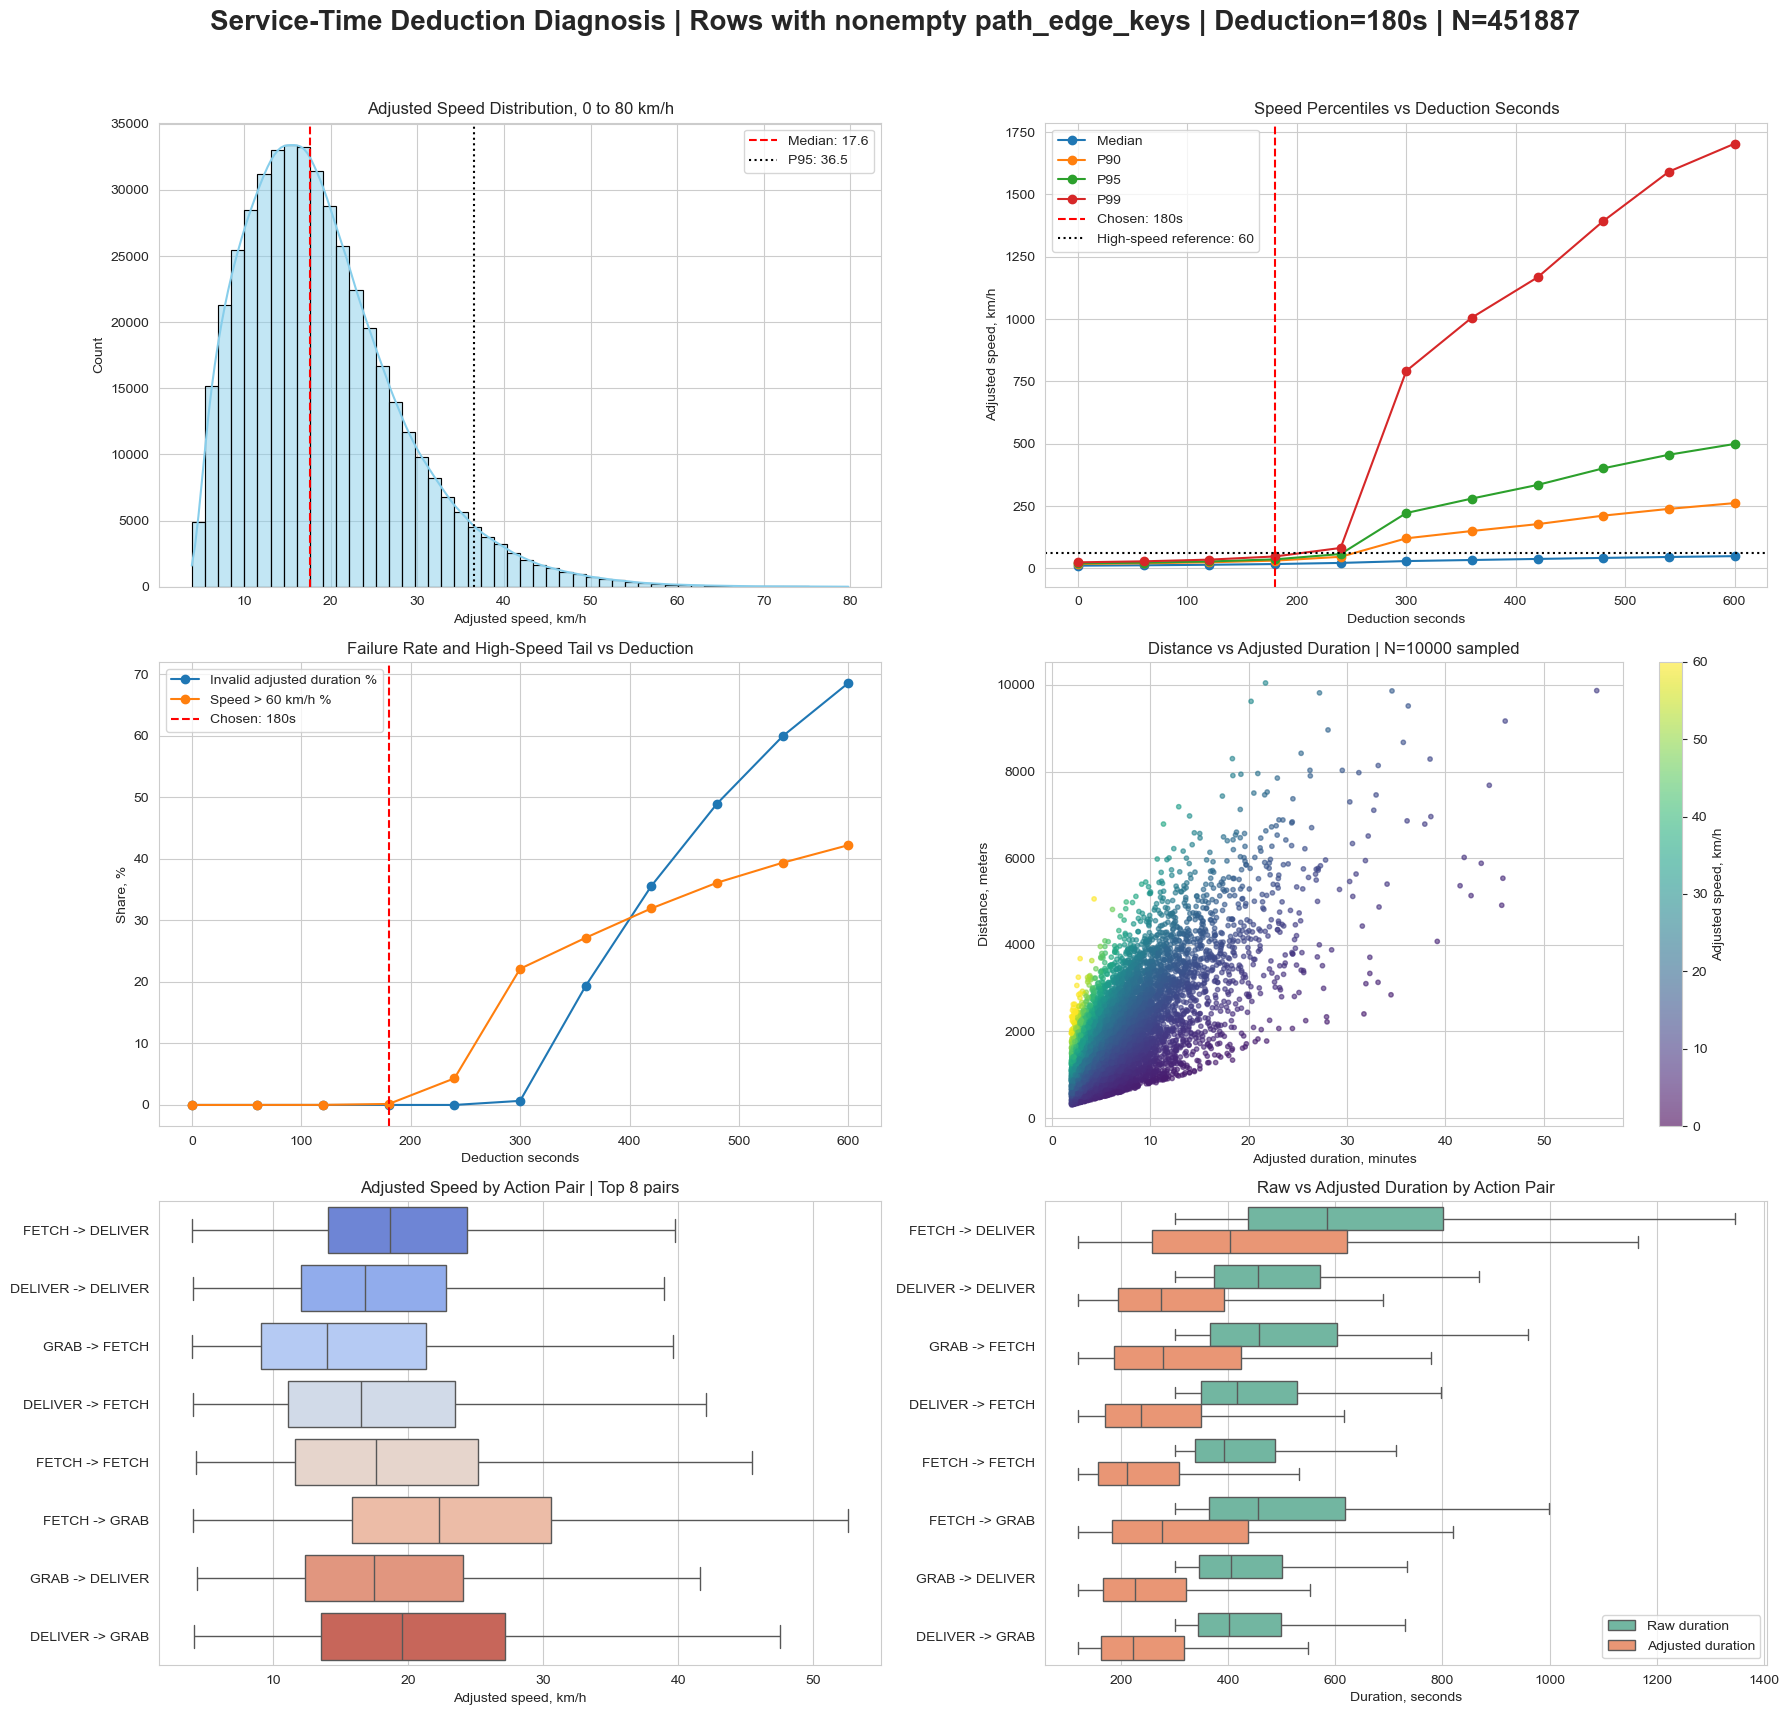


Map-ready adjusted segment table created
Object name: MAP_READY_SEGMENT_TABLE
Rows: 451,887
Has path_edge_keys: True
Nonempty path_edge_keys share: 100.00%


In [5]:
# =========================================================
# 10.4 Diagnose service-time deduction for adjusted speed
#      Aligned with 1_variables_modified output
#      Python 3.8 compatible
# =========================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 10.4.0 Configuration
# =========================================================

RUN_SERVICE_TIME_DEDUCTION_DIAG = True

# Main deduction to inspect in detail.
SERVICE_TIME_DEDUCTION_SEC_TEST = 180

# Candidate deduction seconds to compare.
DEDUCTION_GRID_SEC = [0, 60, 120, 180, 240, 300, 360, 420, 480, 540, 600]

# Action-pair filter.
# Use None to keep all action pairs.
PAIR_TYPES_TO_KEEP = None

# Alternative filter by start/end action separately.
# These are only used when PAIR_TYPES_TO_KEEP is None.
START_ACTIONS_TO_KEEP = None
END_ACTIONS_TO_KEEP = None

# Whether to only use rows that have usable network paths.
ONLY_VALID_NETWORK_FOR_DEDUCTION_DIAG = True

# Distance and duration columns.
DIST_COL_FOR_ADJUSTED_SPEED = "final_distance_m"
DURATION_COL_FOR_ADJUSTED_SPEED = "duration"

# Minimum denominator after deduction.
MIN_ADJUSTED_DURATION_SEC = 1

# Plot controls.
MAX_PLOT_SPEED_ADJ = 80
SPEED_LIMIT_HIGH_ADJ = 60
SPEED_LIMIT_LOW_ADJ = 0.5
SCATTER_SAMPLE_N_DEDUCTION = 10000
TOP_K_PAIRS_DEDUCTION = 12
RANDOM_SEED = 42

# Output files.
try:
    BASE_DIR
except NameError:
    BASE_DIR = Path.cwd()

try:
    OUTPUT_ROOT
except NameError:
    OUTPUT_ROOT = BASE_DIR / "outputs_pipeline_aligned" / "03_diagnostics_maps"

OUTPUT_DIR = OUTPUT_ROOT / "diagnostics" / "service_time_deduction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FIG_SERVICE_TIME_DIAG = OUTPUT_DIR / (
    "service_time_deduction_diagnosis_%ds.png" % SERVICE_TIME_DEDUCTION_SEC_TEST
)
OUTPUT_DEDUCTION_GRID_CSV = OUTPUT_DIR / "service_time_deduction_grid_summary.csv"
OUTPUT_PAIR_DEDUCTION_CSV = OUTPUT_DIR / (
    "service_time_deduction_pair_summary_%ds.csv" % SERVICE_TIME_DEDUCTION_SEC_TEST
)

# This must come from 1_variables_modified output.
SEGMENT_MODEL_CANDIDATES = []

if "SEGMENT_MODEL_CSV_GZ" in globals():
    SEGMENT_MODEL_CANDIDATES.append(Path(SEGMENT_MODEL_CSV_GZ))
if "SEGMENT_MODEL_CSV" in globals():
    SEGMENT_MODEL_CANDIDATES.append(Path(SEGMENT_MODEL_CSV))

SEGMENT_MODEL_CANDIDATES.extend([
    OUTPUT_ROOT / "segments" / "segment_model_table.csv.gz",
    OUTPUT_ROOT / "segments" / "segment_model_table.csv",
    BASE_DIR / "outputs_pipeline_aligned" / "02_variables" / "segments" / "segment_model_table.csv.gz",
    BASE_DIR / "outputs_pipeline_aligned" / "02_variables" / "segments" / "segment_model_table.csv",
])


# =========================================================
# 10.4.1 Helper functions
# =========================================================

def first_existing_path(candidates, label):
    checked = []
    for p in candidates:
        p = Path(p)
        checked.append(str(p))
        if p.exists():
            return p
    raise FileNotFoundError(
        "No existing %s found. Checked: %s" % (label, checked)
    )


def read_segment_model_aligned():
    if "segment_model" in globals() and isinstance(segment_model, pd.DataFrame):
        print("Using in-memory segment_model from 1_variables_modified.")
        out = segment_model.copy()
        path_used = None
    else:
        path_used = first_existing_path(SEGMENT_MODEL_CANDIDATES, "segment model table")
        print("Reading segment model table:", path_used)
        out = pd.read_csv(path_used)

    return out, path_used


def display_table(x, n=30):
    try:
        display(x.head(n))
    except Exception:
        print(x.head(n).to_string())


def _safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"nan", "NaN", "<NA>", "None"}:
        return ""
    return s


def add_pair_type_col(input_df):
    required_cols = ["start_action", "end_action"]
    for c in required_cols:
        if c not in input_df.columns:
            raise ValueError("Missing required column: %s" % c)

    out = input_df.copy()
    out["pair_type"] = (
        out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)
    )
    return out


def filter_action_pairs(input_df):
    out = input_df.copy()

    if PAIR_TYPES_TO_KEEP is not None:
        out = out[out["pair_type"].isin(PAIR_TYPES_TO_KEEP)].copy()
    else:
        if START_ACTIONS_TO_KEEP is not None:
            out = out[out["start_action"].isin(START_ACTIONS_TO_KEEP)].copy()
        if END_ACTIONS_TO_KEEP is not None:
            out = out[out["end_action"].isin(END_ACTIONS_TO_KEEP)].copy()

    return out


def filter_valid_network_rows(input_df):
    out = input_df.copy()

    if not ONLY_VALID_NETWORK_FOR_DEDUCTION_DIAG:
        return out, "All rows"

    if "is_valid_network" in out.columns:
        mask = out["is_valid_network"].fillna(False).astype(bool)
        return out[mask].copy(), "Rows with is_valid_network=True"

    if "path_edge_keys" in out.columns:
        mask = out["path_edge_keys"].fillna("").astype(str).str.len() > 0
        return out[mask].copy(), "Rows with nonempty path_edge_keys"

    if "n_conedges_in_segment" in out.columns:
        mask = pd.to_numeric(out["n_conedges_in_segment"], errors="coerce").fillna(0) > 0
        return out[mask].copy(), "Rows with n_conedges_in_segment>0"

    return out.copy(), "All rows, no network-valid flag found"


def compute_adjusted_speed(input_df, deduction_sec):
    out = input_df.copy()

    out[DURATION_COL_FOR_ADJUSTED_SPEED] = _safe_numeric(
        out[DURATION_COL_FOR_ADJUSTED_SPEED]
    )
    out[DIST_COL_FOR_ADJUSTED_SPEED] = _safe_numeric(
        out[DIST_COL_FOR_ADJUSTED_SPEED]
    )

    out["deduction_sec"] = deduction_sec
    out["adjusted_duration_sec"] = (
        out[DURATION_COL_FOR_ADJUSTED_SPEED] - float(deduction_sec)
    )

    valid_denom = out["adjusted_duration_sec"] > MIN_ADJUSTED_DURATION_SEC
    valid_distance = out[DIST_COL_FOR_ADJUSTED_SPEED] > 0

    out["is_valid_adjusted_speed"] = valid_denom & valid_distance
    out["speed_kmh_adjusted"] = np.nan

    out.loc[out["is_valid_adjusted_speed"], "speed_kmh_adjusted"] = (
        out.loc[out["is_valid_adjusted_speed"], DIST_COL_FOR_ADJUSTED_SPEED]
        / out.loc[out["is_valid_adjusted_speed"], "adjusted_duration_sec"]
        * 3.6
    )

    return out


def summarize_one_deduction(input_df, deduction_sec):
    tmp = compute_adjusted_speed(input_df, deduction_sec)
    valid = tmp[tmp["is_valid_adjusted_speed"]].copy()

    n_total = len(tmp)
    n_valid = len(valid)
    invalid_n = n_total - n_valid
    invalid_pct = invalid_n / n_total * 100 if n_total > 0 else np.nan

    if n_valid == 0:
        return {
            "deduction_sec": deduction_sec,
            "n_total": n_total,
            "n_valid": n_valid,
            "invalid_n": invalid_n,
            "invalid_pct": invalid_pct,
            "mean_speed": np.nan,
            "median_speed": np.nan,
            "p75_speed": np.nan,
            "p90_speed": np.nan,
            "p95_speed": np.nan,
            "p99_speed": np.nan,
            "share_speed_gt_high_pct": np.nan,
            "share_speed_lt_low_pct": np.nan,
            "median_adjusted_duration_sec": np.nan,
        }

    speed = valid["speed_kmh_adjusted"]

    return {
        "deduction_sec": deduction_sec,
        "n_total": n_total,
        "n_valid": n_valid,
        "invalid_n": invalid_n,
        "invalid_pct": invalid_pct,
        "mean_speed": speed.mean(),
        "median_speed": speed.median(),
        "p75_speed": speed.quantile(0.75),
        "p90_speed": speed.quantile(0.90),
        "p95_speed": speed.quantile(0.95),
        "p99_speed": speed.quantile(0.99),
        "share_speed_gt_high_pct": (speed > SPEED_LIMIT_HIGH_ADJ).mean() * 100,
        "share_speed_lt_low_pct": (speed < SPEED_LIMIT_LOW_ADJ).mean() * 100,
        "median_adjusted_duration_sec": valid["adjusted_duration_sec"].median(),
    }


def make_pair_summary(input_df):
    agg_dict = {
        "speed_kmh_adjusted": ["count", "mean", "median", "max"],
        "adjusted_duration_sec": ["mean", "median"],
        DURATION_COL_FOR_ADJUSTED_SPEED: ["mean", "median"],
        DIST_COL_FOR_ADJUSTED_SPEED: ["mean", "median"],
    }

    pair_stats = input_df.groupby("pair_type").agg(agg_dict).round(2)

    flat_cols = []
    for col in pair_stats.columns:
        if isinstance(col, tuple):
            flat_cols.append("_".join([str(x) for x in col if str(x) != ""]))
        else:
            flat_cols.append(str(col))
    pair_stats.columns = flat_cols

    rename_map = {
        "speed_kmh_adjusted_count": "Count",
        "speed_kmh_adjusted_mean": "AdjSpeed_Mean",
        "speed_kmh_adjusted_median": "AdjSpeed_Median",
        "speed_kmh_adjusted_max": "AdjSpeed_Max",
        "adjusted_duration_sec_mean": "AdjTime_Mean",
        "adjusted_duration_sec_median": "AdjTime_Median",
        DURATION_COL_FOR_ADJUSTED_SPEED + "_mean": "RawTime_Mean",
        DURATION_COL_FOR_ADJUSTED_SPEED + "_median": "RawTime_Median",
        DIST_COL_FOR_ADJUSTED_SPEED + "_mean": "Dist_Mean",
        DIST_COL_FOR_ADJUSTED_SPEED + "_median": "Dist_Median",
    }

    pair_stats = pair_stats.rename(columns=rename_map)
    pair_stats = pair_stats.sort_values("Count", ascending=False)
    return pair_stats


# =========================================================
# 10.4.2 Main diagnosis
# =========================================================

if RUN_SERVICE_TIME_DEDUCTION_DIAG:

    df_model_raw, SEGMENT_MODEL_TABLE_USED = read_segment_model_aligned()

    required_cols = [
        "start_action",
        "end_action",
        DURATION_COL_FOR_ADJUSTED_SPEED,
        DIST_COL_FOR_ADJUSTED_SPEED,
    ]
    for c in required_cols:
        if c not in df_model_raw.columns:
            raise ValueError("Missing required column in segment model table: %s" % c)

    if "path_edge_keys" not in df_model_raw.columns:
        print(
            "Warning: path_edge_keys is missing. The diagnosis can still run, "
            "but the map block should use the 1_variables_modified output that contains path_edge_keys."
        )

    base_df, source_label = filter_valid_network_rows(df_model_raw)
    base_df = add_pair_type_col(base_df)
    base_df = filter_action_pairs(base_df)

    if len(base_df) == 0:
        raise ValueError("No rows left after network and action-pair filters.")

    print("\n" + "=" * 70)
    print("Service-time deduction diagnosis, aligned with 1_variables_modified")
    print("=" * 70)
    print("Source:", source_label)
    print("Rows after filters:", len(base_df))
    print("Main deduction tested:", SERVICE_TIME_DEDUCTION_SEC_TEST, "seconds")
    print("Distance column:", DIST_COL_FOR_ADJUSTED_SPEED)
    print("Duration column:", DURATION_COL_FOR_ADJUSTED_SPEED)
    print("Segment model table:", SEGMENT_MODEL_TABLE_USED)

    print("\nAction pair distribution after filters:")
    print(base_df["pair_type"].value_counts(dropna=False).head(30).to_string())

    # -----------------------------------------------------
    # 1. Deduction grid summary
    # -----------------------------------------------------

    grid_rows = []
    for deduction_sec in DEDUCTION_GRID_SEC:
        grid_rows.append(summarize_one_deduction(base_df, deduction_sec))

    deduction_summary = pd.DataFrame(grid_rows).round(3)

    tmp_grid = OUTPUT_DEDUCTION_GRID_CSV.with_suffix(
        OUTPUT_DEDUCTION_GRID_CSV.suffix + ".tmp"
    )
    deduction_summary.to_csv(tmp_grid, index=False)
    os.replace(str(tmp_grid), str(OUTPUT_DEDUCTION_GRID_CSV))

    print("\nDeduction grid summary:")
    display_table(deduction_summary, n=len(deduction_summary))
    print("Saved:", OUTPUT_DEDUCTION_GRID_CSV)

    # -----------------------------------------------------
    # 2. Main adjusted-speed dataset
    # -----------------------------------------------------

    diag_df = compute_adjusted_speed(base_df, SERVICE_TIME_DEDUCTION_SEC_TEST)
    diag_valid = diag_df[diag_df["is_valid_adjusted_speed"]].copy()

    print("\n" + "-" * 70)
    print("Main deduction detailed summary")
    print("-" * 70)

    print("Total rows:", len(diag_df))
    print("Valid adjusted-speed rows:", len(diag_valid))
    print(
        "Invalid adjusted-speed rows: %d, %.2f%%"
        % (
            len(diag_df) - len(diag_valid),
            (len(diag_df) - len(diag_valid)) / len(diag_df) * 100,
        )
    )

    if len(diag_valid) == 0:
        raise ValueError("No valid rows after service-time deduction.")

    speed_stats = diag_valid["speed_kmh_adjusted"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )

    print("\nAdjusted speed summary:")
    print("Mean speed: %.2f km/h" % speed_stats["mean"])
    print("Median speed: %.2f km/h" % speed_stats["50%"])
    print("P90 speed: %.2f km/h" % speed_stats["90%"])
    print("P95 speed: %.2f km/h" % speed_stats["95%"])
    print("P99 speed: %.2f km/h" % speed_stats["99%"])
    print("Max speed: %.2f km/h" % speed_stats["max"])

    high_speed = diag_valid[diag_valid["speed_kmh_adjusted"] > SPEED_LIMIT_HIGH_ADJ]
    low_speed = diag_valid[diag_valid["speed_kmh_adjusted"] < SPEED_LIMIT_LOW_ADJ]

    print(
        "High adjusted speed rows (> %.1f km/h): %d rows, %.2f%%"
        % (
            SPEED_LIMIT_HIGH_ADJ,
            len(high_speed),
            len(high_speed) / len(diag_valid) * 100,
        )
    )
    print(
        "Very low adjusted speed rows (< %.1f km/h): %d rows, %.2f%%"
        % (
            SPEED_LIMIT_LOW_ADJ,
            len(low_speed),
            len(low_speed) / len(diag_valid) * 100,
        )
    )

    # -----------------------------------------------------
    # 3. Pair-level summary under main deduction
    # -----------------------------------------------------

    pair_stats_adj = make_pair_summary(diag_valid)
    pair_stats_adj_out = pair_stats_adj.reset_index()

    tmp_pair = OUTPUT_PAIR_DEDUCTION_CSV.with_suffix(
        OUTPUT_PAIR_DEDUCTION_CSV.suffix + ".tmp"
    )
    pair_stats_adj_out.to_csv(tmp_pair, index=False)
    os.replace(str(tmp_pair), str(OUTPUT_PAIR_DEDUCTION_CSV))

    print("\nPair-level adjusted-speed summary:")
    display_table(pair_stats_adj_out, n=30)
    print("Saved:", OUTPUT_PAIR_DEDUCTION_CSV)

    # -----------------------------------------------------
    # 4. Diagnosis figure
    # -----------------------------------------------------

    print("\nDrawing service-time deduction diagnosis figure...")

    sns.set_style("whitegrid")
    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(3, 2, figsize=(18, 18))

    fig.suptitle(
        "Service-Time Deduction Diagnosis | %s | Deduction=%ds | N=%d"
        % (source_label, SERVICE_TIME_DEDUCTION_SEC_TEST, len(base_df)),
        fontsize=20,
        fontweight="bold",
    )

    # Panel 1. Adjusted speed distribution.
    plot_speed = diag_valid[
        (diag_valid["speed_kmh_adjusted"] >= 0)
        & (diag_valid["speed_kmh_adjusted"] <= MAX_PLOT_SPEED_ADJ)
    ].copy()

    if len(plot_speed) > 0:
        sns.histplot(
            plot_speed["speed_kmh_adjusted"],
            bins=50,
            kde=True,
            color="skyblue",
            edgecolor="black",
            ax=axes[0, 0],
        )

        median_adj = plot_speed["speed_kmh_adjusted"].median()
        p95_adj = plot_speed["speed_kmh_adjusted"].quantile(0.95)

        axes[0, 0].axvline(
            median_adj,
            color="red",
            linestyle="--",
            label="Median: %.1f" % median_adj,
        )
        axes[0, 0].axvline(
            p95_adj,
            color="black",
            linestyle=":",
            label="P95: %.1f" % p95_adj,
        )

    axes[0, 0].set_title(
        "Adjusted Speed Distribution, 0 to %d km/h" % MAX_PLOT_SPEED_ADJ
    )
    axes[0, 0].set_xlabel("Adjusted speed, km/h")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].legend()

    # Panel 2. Speed percentiles over deduction seconds.
    for col, label in [
        ("median_speed", "Median"),
        ("p90_speed", "P90"),
        ("p95_speed", "P95"),
        ("p99_speed", "P99"),
    ]:
        axes[0, 1].plot(
            deduction_summary["deduction_sec"],
            deduction_summary[col],
            marker="o",
            label=label,
        )

    axes[0, 1].axvline(
        SERVICE_TIME_DEDUCTION_SEC_TEST,
        color="red",
        linestyle="--",
        label="Chosen: %ds" % SERVICE_TIME_DEDUCTION_SEC_TEST,
    )
    axes[0, 1].axhline(
        SPEED_LIMIT_HIGH_ADJ,
        color="black",
        linestyle=":",
        label="High-speed reference: %.0f" % SPEED_LIMIT_HIGH_ADJ,
    )
    axes[0, 1].set_title("Speed Percentiles vs Deduction Seconds")
    axes[0, 1].set_xlabel("Deduction seconds")
    axes[0, 1].set_ylabel("Adjusted speed, km/h")
    axes[0, 1].legend()

    # Panel 3. Invalid row share and high-speed share.
    axes[1, 0].plot(
        deduction_summary["deduction_sec"],
        deduction_summary["invalid_pct"],
        marker="o",
        label="Invalid adjusted duration %",
    )
    axes[1, 0].plot(
        deduction_summary["deduction_sec"],
        deduction_summary["share_speed_gt_high_pct"],
        marker="o",
        label="Speed > %.0f km/h %%" % SPEED_LIMIT_HIGH_ADJ,
    )
    axes[1, 0].axvline(
        SERVICE_TIME_DEDUCTION_SEC_TEST,
        color="red",
        linestyle="--",
        label="Chosen: %ds" % SERVICE_TIME_DEDUCTION_SEC_TEST,
    )
    axes[1, 0].set_title("Failure Rate and High-Speed Tail vs Deduction")
    axes[1, 0].set_xlabel("Deduction seconds")
    axes[1, 0].set_ylabel("Share, %")
    axes[1, 0].legend()

    # Panel 4. Distance vs adjusted duration scatter.
    scatter_source = diag_valid[
        (diag_valid["speed_kmh_adjusted"] >= 0)
        & (diag_valid["speed_kmh_adjusted"] <= MAX_PLOT_SPEED_ADJ * 1.5)
    ].copy()

    sample_size = min(SCATTER_SAMPLE_N_DEDUCTION, len(scatter_source))
    if sample_size > 0:
        sample_df = scatter_source.sample(sample_size, random_state=RANDOM_SEED)

        sc = axes[1, 1].scatter(
            sample_df["adjusted_duration_sec"] / 60.0,
            sample_df[DIST_COL_FOR_ADJUSTED_SPEED],
            c=sample_df["speed_kmh_adjusted"],
            cmap="viridis",
            alpha=0.6,
            s=10,
            vmin=0,
            vmax=min(60, MAX_PLOT_SPEED_ADJ),
        )
        cbar = plt.colorbar(sc, ax=axes[1, 1])
        cbar.set_label("Adjusted speed, km/h")

    axes[1, 1].set_title(
        "Distance vs Adjusted Duration | N=%d sampled" % sample_size
    )
    axes[1, 1].set_xlabel("Adjusted duration, minutes")
    axes[1, 1].set_ylabel("Distance, meters")

    # Panel 5. Adjusted speed by top action pairs.
    top_pairs = pair_stats_adj.index[:TOP_K_PAIRS_DEDUCTION].tolist()
    plot_pair_df = diag_valid[diag_valid["pair_type"].isin(top_pairs)].copy()

    if len(plot_pair_df) > 0:
        sns.boxplot(
            x="speed_kmh_adjusted",
            y="pair_type",
            data=plot_pair_df,
            order=top_pairs,
            showfliers=False,
            palette="coolwarm",
            ax=axes[2, 0],
        )

    axes[2, 0].set_title(
        "Adjusted Speed by Action Pair | Top %d pairs" % len(top_pairs)
    )
    axes[2, 0].set_xlabel("Adjusted speed, km/h")
    axes[2, 0].set_ylabel("")

    # Panel 6. Raw duration vs adjusted duration by top action pairs.
    pair_duration_plot = plot_pair_df.copy()

    if len(pair_duration_plot) > 0:
        duration_long = pair_duration_plot[
            [
                "pair_type",
                DURATION_COL_FOR_ADJUSTED_SPEED,
                "adjusted_duration_sec",
            ]
        ].rename(
            columns={
                DURATION_COL_FOR_ADJUSTED_SPEED: "Raw duration",
                "adjusted_duration_sec": "Adjusted duration",
            }
        )

        duration_long = duration_long.melt(
            id_vars="pair_type",
            value_vars=["Raw duration", "Adjusted duration"],
            var_name="duration_type",
            value_name="duration_sec",
        )

        sns.boxplot(
            x="duration_sec",
            y="pair_type",
            hue="duration_type",
            data=duration_long,
            order=top_pairs,
            showfliers=False,
            palette="Set2",
            ax=axes[2, 1],
        )

    axes[2, 1].set_title("Raw vs Adjusted Duration by Action Pair")
    axes[2, 1].set_xlabel("Duration, seconds")
    axes[2, 1].set_ylabel("")
    axes[2, 1].legend(title="")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    tmp_path = OUTPUT_FIG_SERVICE_TIME_DIAG.with_suffix(
        OUTPUT_FIG_SERVICE_TIME_DIAG.suffix + ".tmp.png"
    )
    plt.savefig(tmp_path, dpi=150)
    os.replace(str(tmp_path), str(OUTPUT_FIG_SERVICE_TIME_DIAG))

    print("Saved:", OUTPUT_FIG_SERVICE_TIME_DIAG)
    plt.show()

    # This is the table used by the map block below.
    MAP_READY_SEGMENT_TABLE = diag_valid.copy()

    print("\n" + "=" * 70)
    print("Map-ready adjusted segment table created")
    print("=" * 70)
    print("Object name: MAP_READY_SEGMENT_TABLE")
    print("Rows:", f"{len(MAP_READY_SEGMENT_TABLE):,}")
    print("Has path_edge_keys:", "path_edge_keys" in MAP_READY_SEGMENT_TABLE.columns)
    if "path_edge_keys" in MAP_READY_SEGMENT_TABLE.columns:
        nonempty_path_share = (
            MAP_READY_SEGMENT_TABLE["path_edge_keys"]
            .fillna("")
            .astype(str)
            .str.len()
            .gt(0)
            .mean()
            * 100
        )
        print("Nonempty path_edge_keys share: %.2f%%" % nonempty_path_share)


## 2. Adjusted-speed map from path keys


In [6]:
# =========================================================
# 10.5 Adjusted-speed map from 1_variables_modified path_edge_keys
#      No filtered csv, no re-snapping, with GraphML path audit
#      Python 3.8 compatible
# =========================================================

import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import osmnx as ox
from tqdm import tqdm


# =========================================================
# 10.5.0 Configuration
# =========================================================

RUN_PATHKEY_ADJUSTED_SPEED_MAP = True

# Use the same deduction from Block 1.
try:
    PATHKEY_MAP_DEDUCTION_SEC = SERVICE_TIME_DEDUCTION_SEC_TEST
except NameError:
    PATHKEY_MAP_DEDUCTION_SEC = 180

PATHKEY_FAST_SPEED_THRESHOLD = 20.0
PATHKEY_MIN_EDGE_TRAVERSALS = 10
PATHKEY_TZ_SHIFT_HOURS = 8

# If the map still looks too sparse, lower this to 3 or 5 for diagnosis.
# For final figures, 10 is cleaner.
PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG = PATHKEY_MIN_EDGE_TRAVERSALS

PATHKEY_TIME_WINDOWS = {
    "Midnight (02:00-06:00)": (2, 6),
    "Midday Peak (10:00-14:00)": (10, 14),
    "Evening Peak (16:00-20:00)": (16, 20),
}
PATHKEY_ALL_LABEL = "Overall (All Hours)"

PATHKEY_SPEED_COL = "speed_kmh_adjusted"
PATHKEY_DIST_COL = "final_distance_m"
PATHKEY_DURATION_COL = "duration"

# Force rebuild while diagnosing path alignment.
FORCE_REBUILD_PATHKEY_EDGE_STATS = True
FORCE_REDRAW_PATHKEY_MAP = True

# Output directory.
try:
    OUTPUT_ROOT
except NameError:
    OUTPUT_ROOT = Path.cwd() / "outputs_pipeline_aligned" / "03_diagnostics_maps"

PATHKEY_MAP_OUTPUT_DIR = OUTPUT_ROOT / "maps" / "adjusted_speed_pathkeys"
PATHKEY_MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATHKEY_OUT_12PANEL = PATHKEY_MAP_OUTPUT_DIR / (
    "map_12panel_pathkeys_adjusted_deduct_%ds_fast_%.0f_mintrav_%d.png"
    % (
        PATHKEY_MAP_DEDUCTION_SEC,
        PATHKEY_FAST_SPEED_THRESHOLD,
        PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG,
    )
)

PATHKEY_AUDIT_CSV = PATHKEY_MAP_OUTPUT_DIR / (
    "pathkey_graph_alignment_audit_deduct_%ds.csv" % PATHKEY_MAP_DEDUCTION_SEC
)

# Plot style.
BG_FIG = "black"
BG_AX = "black"
BASE_EDGE_COLOR = "#333333"
BASE_EDGE_LW = 0.3
BASE_EDGE_ALPHA = 0.6

CMAP_SPEED = "RdYlGn"
CMAP_FLOW = "plasma"
CMAP_FASTSHARE = "magma"

FLOW_LW_MIN = 0.8
FLOW_LW_MAX = 6.0
METRIC_LW = 2.0

P_LOW = 2
P_HIGH = 98

TITLE_FONTSIZE = 24
ROWLABEL_FONTSIZE = 24
CBAR_LABEL_FONTSIZE = 16
CBAR_TICK_FONTSIZE = 12
SUPTITLE_FONTSIZE = 30

CBAR_PAD = 0.01
CBAR_WIDTH = 0.012
RIGHT_MARGIN = 0.92


# =========================================================
# 10.5.1 Path and data helpers
# =========================================================

def pathkey_first_existing(candidates, label):
    checked = []
    for p in candidates:
        if p is None:
            continue
        p = Path(p)
        checked.append(str(p))
        if p.exists():
            return p
    raise FileNotFoundError(
        "No existing %s found. Checked: %s" % (label, checked)
    )


def pathkey_read_effective_paths():
    candidates = []

    if "PATH_INFO_JSON" in globals():
        candidates.append(Path(PATH_INFO_JSON))

    candidates.extend([
        OUTPUT_ROOT / "effective_paths.json",
        PIPELINE_ROOT / "02_variables" / "effective_paths.json",
    ])

    for p in candidates:
        if p.exists():
            try:
                return json.loads(p.read_text(encoding="utf-8"))
            except Exception:
                pass

    return {}


def pathkey_find_graphml():
    effective_paths = pathkey_read_effective_paths()

    candidates = []

    if "GRAPHML_PATH" in globals():
        candidates.append(Path(GRAPHML_PATH))

    if "GRAPH_FILE" in globals():
        candidates.append(Path(GRAPH_FILE))

    if effective_paths.get("graphml_path"):
        candidates.append(Path(effective_paths["graphml_path"]))

    candidates.extend([
        PIPELINE_ROOT / "00_graph" / "baoding_aligned.graphml",
    ])

    return pathkey_first_existing(candidates, "GraphML")


def pathkey_load_map_table():
    if "MAP_READY_SEGMENT_TABLE" in globals() and isinstance(MAP_READY_SEGMENT_TABLE, pd.DataFrame):
        print("Using MAP_READY_SEGMENT_TABLE from Block 1.")
        return MAP_READY_SEGMENT_TABLE.copy(), None

    if "diag_valid" in globals() and isinstance(diag_valid, pd.DataFrame):
        print("Using diag_valid from Block 1.")
        return diag_valid.copy(), None

    if "segment_model" in globals() and isinstance(segment_model, pd.DataFrame):
        print("Using in-memory segment_model, then recomputing adjusted speed.")
        df = segment_model.copy()
    else:
        candidates = []
        if "SEGMENT_MODEL_CSV_GZ" in globals():
            candidates.append(Path(SEGMENT_MODEL_CSV_GZ))
        if "SEGMENT_MODEL_CSV" in globals():
            candidates.append(Path(SEGMENT_MODEL_CSV))

        candidates.extend([
            PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv.gz",
            PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv",
            PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv.gz",
            PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv",
        ])

        model_path = pathkey_first_existing(candidates, "segment_model_table from 1_variables_modified")
        print("Reading segment model table:", model_path)
        df = pd.read_csv(model_path)

    if PATHKEY_SPEED_COL not in df.columns:
        df[PATHKEY_DURATION_COL] = pd.to_numeric(df[PATHKEY_DURATION_COL], errors="coerce")
        df[PATHKEY_DIST_COL] = pd.to_numeric(df[PATHKEY_DIST_COL], errors="coerce")
        df["adjusted_duration_sec"] = df[PATHKEY_DURATION_COL] - float(PATHKEY_MAP_DEDUCTION_SEC)
        valid = (
            df[PATHKEY_DURATION_COL].notna()
            & df[PATHKEY_DIST_COL].notna()
            & (df[PATHKEY_DIST_COL] > 0)
            & (df["adjusted_duration_sec"] > 1)
        )
        df[PATHKEY_SPEED_COL] = np.nan
        df.loc[valid, PATHKEY_SPEED_COL] = (
            df.loc[valid, PATHKEY_DIST_COL]
            / df.loc[valid, "adjusted_duration_sec"]
            * 3.6
        )

    return df.copy(), None


def pathkey_norm_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"nan", "NaN", "<NA>", "None"}:
        return ""
    return s


def pathkey_safe_slug(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "window"


def parse_path_edge_keys_to_pairs(s):
    s = pathkey_norm_text(s)
    if s == "":
        return []

    pairs = []
    for part in s.split(";"):
        part = pathkey_norm_text(part)
        if part == "":
            continue

        bits = part.split("|")
        if len(bits) < 2:
            continue

        try:
            u = int(float(bits[0]))
            v = int(float(bits[1]))
        except Exception:
            continue

        if u == v:
            continue

        if u < v:
            pairs.append((u, v))
        else:
            pairs.append((v, u))

    clean = []
    for p in pairs:
        if len(clean) == 0 or clean[-1] != p:
            clean.append(p)

    return clean


def pathkey_build_unique_graph_edges(graphml_path):
    print("Loading GraphML:", graphml_path)

    G = ox.load_graphml(str(graphml_path))
    G_und = ox.convert.to_undirected(G)

    try:
        gdf_edges = ox.graph_to_gdfs(
            G_und,
            nodes=False,
            fill_edge_geometry=True,
        ).reset_index()
    except TypeError:
        gdf_edges = ox.graph_to_gdfs(G_und, nodes=False).reset_index()

    if "geometry" not in gdf_edges.columns:
        raise ValueError("Graph edges have no geometry column.")

    gdf_edges["u"] = gdf_edges["u"].astype(int)
    gdf_edges["v"] = gdf_edges["v"].astype(int)

    gdf_edges["u2"] = np.minimum(
        gdf_edges["u"].values,
        gdf_edges["v"].values,
    )
    gdf_edges["v2"] = np.maximum(
        gdf_edges["u"].values,
        gdf_edges["v"].values,
    )

    # Avoid leading underscore column names because pandas itertuples may rename them.
    if "length" in gdf_edges.columns:
        gdf_edges["edge_len_m_for_map"] = pd.to_numeric(
            gdf_edges["length"],
            errors="coerce",
        )
    else:
        gdf_edges["edge_len_m_for_map"] = np.nan

    # Fallback only. If graph is projected, geometry.length is meters.
    # If graph is geographic, this value is not meters, but it is only used when length is missing.
    try:
        geom_len = gdf_edges.geometry.length
        gdf_edges["edge_len_m_for_map"] = gdf_edges["edge_len_m_for_map"].where(
            gdf_edges["edge_len_m_for_map"].notna(),
            geom_len,
        )
    except Exception:
        pass

    # Match 1_variables_modified logic, which uses undirected u|v path keys.
    # If there are parallel records for the same node pair, keep the shortest geometry.
    gdf_sorted = gdf_edges.sort_values(
        ["u2", "v2", "edge_len_m_for_map"],
        na_position="last",
    ).copy()

    gdf_unique = (
        gdf_sorted
        .groupby(["u2", "v2"], as_index=False)
        .head(1)
        .copy()
        .reset_index(drop=True)
    )

    edge_len = {}
    for u2, v2, L in zip(
        gdf_unique["u2"].values,
        gdf_unique["v2"].values,
        gdf_unique["edge_len_m_for_map"].values,
    ):
        if pd.notna(L):
            edge_len[(int(u2), int(v2))] = float(L)

    graph_pair_set = set(
        zip(
            gdf_unique["u2"].astype(int).values,
            gdf_unique["v2"].astype(int).values,
        )
    )

    print("Raw graph edge rows:", f"{len(gdf_edges):,}")
    print("Unique undirected node-pair edges:", f"{len(gdf_unique):,}")

    if len(edge_len) == 0:
        print("Warning: no usable edge length values found.")

    return gdf_unique, edge_len, graph_pair_set


def pathkey_prepare_map_rows(df, edge_len, graph_pair_set):
    out = df.copy()

    required_cols = ["path_edge_keys", PATHKEY_SPEED_COL, "start_time"]
    for c in required_cols:
        if c not in out.columns:
            raise ValueError(
                "Missing required column for path-key map: %s. "
                "Rerun 1_variables_modified and Block 1." % c
            )

    out[PATHKEY_SPEED_COL] = pd.to_numeric(out[PATHKEY_SPEED_COL], errors="coerce")
    out[PATHKEY_DIST_COL] = pd.to_numeric(out[PATHKEY_DIST_COL], errors="coerce")

    out = out[out[PATHKEY_SPEED_COL].notna()].copy()
    out = out[out["path_edge_keys"].fillna("").astype(str).str.len() > 0].copy()

    path_pairs = []
    edge_count = []
    graph_match_count = []
    graph_missing_count = []
    path_len_m = []

    for s in tqdm(out["path_edge_keys"], total=len(out), desc="parse path_edge_keys"):
        pairs = parse_path_edge_keys_to_pairs(s)
        path_pairs.append(pairs)
        edge_count.append(len(pairs))

        match_n = 0
        missing_n = 0
        total_len = 0.0

        for p in pairs:
            if p in graph_pair_set:
                match_n += 1
                L = edge_len.get(p, np.nan)
                if np.isfinite(L) and L > 0:
                    total_len += float(L)
            else:
                missing_n += 1

        graph_match_count.append(match_n)
        graph_missing_count.append(missing_n)
        path_len_m.append(total_len if match_n > 0 else np.nan)

    out["map_edge_pairs"] = path_pairs
    out["map_edge_count"] = edge_count
    out["map_graph_match_count"] = graph_match_count
    out["map_graph_missing_count"] = graph_missing_count
    out["map_path_len_m"] = path_len_m
    out["map_graph_missing_share"] = (
        out["map_graph_missing_count"]
        / out["map_edge_count"].replace(0, np.nan)
    )

    out["map_len_to_final_dist_ratio"] = (
        out["map_path_len_m"]
        / out[PATHKEY_DIST_COL].replace(0, np.nan)
    )

    out["dt_obj_utc"] = pd.to_datetime(
        out["start_time"],
        unit="s",
        utc=True,
        errors="coerce",
    )
    out["dt_obj_local"] = out["dt_obj_utc"] + pd.Timedelta(hours=PATHKEY_TZ_SHIFT_HOURS)
    out["hour"] = out["dt_obj_local"].dt.hour

    out = out[out["hour"].notna()].copy()
    out["hour"] = out["hour"].astype(int)

    out = out[out["map_edge_count"] > 0].copy()
    out = out[out["map_graph_match_count"] > 0].copy()

    return out


def pathkey_edge_stats_path(label):
    return PATHKEY_MAP_OUTPUT_DIR / (
        "edge_stats_pathkeys_%s_deduct_%ds_fast_%.0f_mintrav_%d.csv"
        % (
            pathkey_safe_slug(label),
            PATHKEY_MAP_DEDUCTION_SEC,
            PATHKEY_FAST_SPEED_THRESHOLD,
            PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG,
        )
    )


def build_edge_stats_from_pathkeys(df_window, graph_pair_set):
    edge_stats = {}

    iterator = tqdm(df_window.itertuples(index=False), total=len(df_window), desc="edge stats")
    for row in iterator:
        trip_speed = getattr(row, PATHKEY_SPEED_COL)

        if not np.isfinite(trip_speed):
            continue

        pairs = getattr(row, "map_edge_pairs")
        if len(pairs) == 0:
            continue

        is_fast = 1 if trip_speed > PATHKEY_FAST_SPEED_THRESHOLD else 0

        for key in pairs:
            if key not in graph_pair_set:
                continue

            if key not in edge_stats:
                edge_stats[key] = {
                    "sum_speed": 0.0,
                    "count": 0,
                    "fast_count": 0,
                }

            edge_stats[key]["sum_speed"] += float(trip_speed)
            edge_stats[key]["count"] += 1
            edge_stats[key]["fast_count"] += is_fast

    rows = []
    for key, s in edge_stats.items():
        u2, v2 = key
        cnt = int(s["count"])
        rows.append({
            "u2": int(u2),
            "v2": int(v2),
            "avg_adjusted_speed": float(s["sum_speed"]) / cnt if cnt > 0 else np.nan,
            "frequency": cnt,
            "fast_share_adjusted": float(s["fast_count"]) / cnt if cnt > 0 else np.nan,
        })

    if len(rows) == 0:
        return pd.DataFrame(
            columns=["u2", "v2", "avg_adjusted_speed", "frequency", "fast_share_adjusted"]
        )

    return pd.DataFrame(rows)


def get_or_build_pathkey_edge_stats(label, df_window, graph_pair_set):
    path = pathkey_edge_stats_path(label)
    required = {"u2", "v2", "avg_adjusted_speed", "frequency", "fast_share_adjusted"}

    if (not FORCE_REBUILD_PATHKEY_EDGE_STATS) and path.exists():
        try:
            cols = set(pd.read_csv(path, nrows=0).columns)
            if required.issubset(cols):
                print("Reuse path-key edge stats:", path)
                return pd.read_csv(path)
        except Exception as exc:
            print("Cannot reuse path-key edge stats:", exc)

    stats = build_edge_stats_from_pathkeys(df_window, graph_pair_set)

    tmp = path.with_suffix(path.suffix + ".tmp")
    stats.to_csv(tmp, index=False)
    os.replace(str(tmp), str(path))

    print("Saved path-key edge stats:", path)
    return stats


# =========================================================
# 10.5.2 Main map pipeline
# =========================================================

if RUN_PATHKEY_ADJUSTED_SPEED_MAP:

    print("\n" + "=" * 80)
    print("Adjusted-speed map using 1_variables_modified path_edge_keys")
    print("=" * 80)

    graphml_path = pathkey_find_graphml()
    gdf_edges_base, graph_edge_len, graph_pair_set = pathkey_build_unique_graph_edges(graphml_path)

    df_map_raw, _ = pathkey_load_map_table()

    print("\nMap input rows before path-key audit:", f"{len(df_map_raw):,}")
    print("Deduction seconds:", PATHKEY_MAP_DEDUCTION_SEC)
    print("Adjusted fast-speed threshold:", PATHKEY_FAST_SPEED_THRESHOLD)
    print("Minimum edge traversals:", PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG)

    if "pair_type" not in df_map_raw.columns and {"start_action", "end_action"}.issubset(df_map_raw.columns):
        df_map_raw["pair_type"] = (
            df_map_raw["start_action"].astype(str) + " -> " + df_map_raw["end_action"].astype(str)
        )

    df_map = pathkey_prepare_map_rows(df_map_raw, graph_edge_len, graph_pair_set)

    if len(df_map) == 0:
        raise ValueError(
            "No rows left for mapping after path-key and GraphML alignment checks."
        )

    # =====================================================
    # 10.5.3 Path audit
    # =====================================================

    audit_cols = [
        "seg_id",
        "pair_type",
        "start_action",
        "end_action",
        PATHKEY_DURATION_COL,
        "adjusted_duration_sec",
        PATHKEY_DIST_COL,
        PATHKEY_SPEED_COL,
        "map_edge_count",
        "map_graph_match_count",
        "map_graph_missing_count",
        "map_graph_missing_share",
        "map_path_len_m",
        "map_len_to_final_dist_ratio",
        "path_edge_keys",
    ]
    audit_cols = [c for c in audit_cols if c in df_map.columns]

    audit_out = df_map[audit_cols].copy()
    tmp_audit = PATHKEY_AUDIT_CSV.with_suffix(PATHKEY_AUDIT_CSV.suffix + ".tmp")
    audit_out.to_csv(tmp_audit, index=False)
    os.replace(str(tmp_audit), str(PATHKEY_AUDIT_CSV))

    print("\nPath-key audit saved:", PATHKEY_AUDIT_CSV)
    print("Rows used after path-key audit:", f"{len(df_map):,}")

    print("\nGraph missing share summary:")
    print(
        df_map["map_graph_missing_share"]
        .replace([np.inf, -np.inf], np.nan)
        .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
        .round(4)
        .to_string()
    )

    mean_missing_share = float(
        df_map["map_graph_missing_share"]
        .replace([np.inf, -np.inf], np.nan)
        .mean()
    )
    if mean_missing_share > 0.02:
        raise ValueError(
            "GraphML and path_edge_keys are not aligned. "
            "Mean missing edge share is %.4f. Rerun notebooks 01 and 02 from scratch."
            % mean_missing_share
        )

    print("\nPath edge count summary:")
    print(
        df_map["map_edge_count"]
        .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
        .round(2)
        .to_string()
    )

    ratio_valid = (
        df_map["map_len_to_final_dist_ratio"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    print("\nMapped path length / final_distance_m ratio:")
    if len(ratio_valid) > 0:
        print(
            ratio_valid
            .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
            .round(3)
            .to_string()
        )
    else:
        print("No valid ratio values.")

    if "pair_type" in df_map.columns:
        pair_audit = (
            df_map.groupby("pair_type")
            .agg(
                n=("map_edge_count", "size"),
                median_edge_count=("map_edge_count", "median"),
                mean_graph_missing_share=("map_graph_missing_share", "mean"),
                median_len_ratio=("map_len_to_final_dist_ratio", "median"),
                p95_len_ratio=("map_len_to_final_dist_ratio", lambda x: x.replace([np.inf, -np.inf], np.nan).quantile(0.95)),
                median_adjusted_speed=(PATHKEY_SPEED_COL, "median"),
            )
            .reset_index()
            .sort_values("n", ascending=False)
        )

        print("\nPath audit by action pair:")
        try:
            display(pair_audit.head(30))
        except Exception:
            print(pair_audit.head(30).to_string(index=False))

    suspicious = df_map[
        (df_map["map_edge_count"] <= 0)
        | (df_map["map_graph_missing_share"] > 0.05)
        | (df_map["map_len_to_final_dist_ratio"] < 0.5)
        | (df_map["map_len_to_final_dist_ratio"] > 2.5)
    ].copy()

    print("\nSuspicious mapped rows:")
    print("Count:", f"{len(suspicious):,}", "Share: %.2f%%" % (len(suspicious) / len(df_map) * 100))

    if len(suspicious) > 0:
        sample_cols = [
            "seg_id",
            "pair_type",
            PATHKEY_DIST_COL,
            "map_path_len_m",
            "map_len_to_final_dist_ratio",
            "map_edge_count",
            "map_graph_missing_share",
            PATHKEY_SPEED_COL,
        ]
        sample_cols = [c for c in sample_cols if c in suspicious.columns]
        try:
            display(suspicious[sample_cols].head(20))
        except Exception:
            print(suspicious[sample_cols].head(20).to_string(index=False))

    # =====================================================
    # 10.5.4 Build edge statistics by time window
    # =====================================================

    window_order = list(PATHKEY_TIME_WINDOWS.keys()) + [PATHKEY_ALL_LABEL]
    window_gdfs = {}

    all_speeds = []
    all_flows = []
    all_fast = []

    for label in window_order:
        print("\nWindow:", label)

        if label == PATHKEY_ALL_LABEL:
            df_w = df_map.copy()
        else:
            h0, h1 = PATHKEY_TIME_WINDOWS[label]
            df_w = df_map[(df_map["hour"] >= h0) & (df_map["hour"] < h1)].copy()

        print("Rows in window:", f"{len(df_w):,}")

        df_edge_stats = get_or_build_pathkey_edge_stats(
            label=label,
            df_window=df_w,
            graph_pair_set=graph_pair_set,
        )

        print("Covered undirected edges:", f"{len(df_edge_stats):,}")

        gdf_w = gdf_edges_base.merge(df_edge_stats, on=["u2", "v2"], how="left")
        gdf_w["frequency"] = gdf_w["frequency"].fillna(0).astype(int)

        gdf_active = gdf_w[
            gdf_w["frequency"] >= PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG
        ].copy()

        window_gdfs[label] = gdf_active

        if len(gdf_active) > 0:
            all_speeds.append(gdf_active["avg_adjusted_speed"].values.astype(float))
            all_flows.append(gdf_active["frequency"].values.astype(float))
            all_fast.append(gdf_active["fast_share_adjusted"].values.astype(float))

    if len(all_speeds) == 0:
        raise RuntimeError(
            "No active edges found. Lower PATHKEY_MIN_EDGE_TRAVERSALS_FOR_DEBUG to 3 or 5."
        )

    # =====================================================
    # 10.5.5 Shared color scales
    # =====================================================

    all_speeds_concat = np.concatenate(
        [x[np.isfinite(x)] for x in all_speeds if len(x) > 0]
    )
    vmin_s = float(np.nanpercentile(all_speeds_concat, P_LOW))
    vmax_s = float(np.nanpercentile(all_speeds_concat, P_HIGH))
    vmin_s = max(0.5, vmin_s)
    vmax_s = max(vmax_s, vmin_s + 0.1)
    norm_speed = mcolors.Normalize(vmin=vmin_s, vmax=vmax_s, clip=True)

    all_flows_concat = np.concatenate([x for x in all_flows if len(x) > 0])
    flow_min = max(1.0, float(np.nanpercentile(all_flows_concat, P_LOW)))
    flow_max = float(np.nanpercentile(all_flows_concat, P_HIGH))
    flow_max = max(flow_max, flow_min + 1.0)
    norm_flow = mcolors.LogNorm(vmin=flow_min, vmax=flow_max, clip=True)

    all_fast_concat = np.concatenate(
        [x[np.isfinite(x)] for x in all_fast if len(x) > 0]
    )
    fr_min = float(np.nanpercentile(all_fast_concat, P_LOW))
    fr_max = float(np.nanpercentile(all_fast_concat, P_HIGH))
    fr_min = max(0.0, fr_min)
    fr_max = min(1.0, fr_max)
    fr_max = max(fr_max, fr_min + 1e-3)
    norm_fast = mcolors.Normalize(vmin=fr_min, vmax=fr_max, clip=True)

    print("\nShared legends")
    print("adjusted speed vmin=%.2f, vmax=%.2f" % (vmin_s, vmax_s))
    print("flow           vmin=%.0f, vmax=%.0f, log scale" % (flow_min, flow_max))
    print("fast share     vmin=%.3f, vmax=%.3f" % (fr_min, fr_max))

    # =====================================================
    # 10.5.6 Draw 3 x 4 map panel
    # =====================================================

    if PATHKEY_OUT_12PANEL.exists() and not FORCE_REDRAW_PATHKEY_MAP:
        print("Path-key adjusted-speed map already exists, skip drawing:")
        print(PATHKEY_OUT_12PANEL)

    else:
        print("\nDrawing path-key adjusted-speed map...")

        fig, axes = plt.subplots(3, 4, figsize=(52, 30), facecolor=BG_FIG)

        row_titles = [
            "Flow Count on Edges",
            "Average Adjusted Speed on Edges (km/h)",
            "Share of Trips with Adjusted Speed > %.0f km/h" % PATHKEY_FAST_SPEED_THRESHOLD,
        ]

        for r in range(3):
            for c, label in enumerate(window_order):
                ax = axes[r, c]
                ax.set_facecolor(BG_AX)

                gdf_edges_base.plot(
                    ax=ax,
                    color=BASE_EDGE_COLOR,
                    linewidth=BASE_EDGE_LW,
                    alpha=BASE_EDGE_ALPHA,
                    zorder=1,
                )

                gdf_active = window_gdfs.get(label, None)

                if gdf_active is not None and len(gdf_active) > 0:

                    if r == 0:
                        freq = gdf_active["frequency"].astype(float).values

                        if len(freq) > 1 and freq.max() > freq.min():
                            lw = np.interp(
                                freq,
                                (freq.min(), freq.max()),
                                (FLOW_LW_MIN, FLOW_LW_MAX),
                            )
                        else:
                            lw = np.full(len(freq), 2.0)

                        gdf_active.plot(
                            ax=ax,
                            column="frequency",
                            cmap=CMAP_FLOW,
                            linewidth=lw,
                            norm=norm_flow,
                            zorder=2,
                        )

                    elif r == 1:
                        gdf_active.plot(
                            ax=ax,
                            column="avg_adjusted_speed",
                            cmap=CMAP_SPEED,
                            linewidth=METRIC_LW,
                            norm=norm_speed,
                            zorder=2,
                        )

                    else:
                        gdf_active.plot(
                            ax=ax,
                            column="fast_share_adjusted",
                            cmap=CMAP_FASTSHARE,
                            linewidth=METRIC_LW,
                            norm=norm_fast,
                            zorder=2,
                        )

                if r == 0:
                    ax.set_title(
                        label,
                        fontsize=TITLE_FONTSIZE,
                        color="white",
                        pad=14,
                    )

                ax.axis("off")

        for r, title in enumerate(row_titles):
            axes[r, 0].text(
                -0.03,
                0.5,
                title,
                transform=axes[r, 0].transAxes,
                rotation=90,
                fontsize=ROWLABEL_FONTSIZE,
                color="white",
                va="center",
                ha="right",
            )

        plt.subplots_adjust(
            left=0.02,
            right=RIGHT_MARGIN,
            top=0.96,
            bottom=0.02,
            wspace=0.02,
            hspace=0.04,
        )

        cax_flow = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.68, CBAR_WIDTH, 0.22])
        cax_speed = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.38, CBAR_WIDTH, 0.22])
        cax_fast = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.08, CBAR_WIDTH, 0.22])

        sm_flow = plt.cm.ScalarMappable(cmap=CMAP_FLOW, norm=norm_flow)
        sm_flow.set_array([])
        cbar1 = fig.colorbar(sm_flow, cax=cax_flow)
        cbar1.set_label(
            "Trip Count (Log Scale)",
            color="white",
            fontsize=CBAR_LABEL_FONTSIZE,
        )
        cbar1.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

        sm_speed = plt.cm.ScalarMappable(cmap=CMAP_SPEED, norm=norm_speed)
        sm_speed.set_array([])
        cbar2 = fig.colorbar(sm_speed, cax=cax_speed)
        cbar2.set_label(
            "Avg Adjusted Speed (km/h)",
            color="white",
            fontsize=CBAR_LABEL_FONTSIZE,
        )
        cbar2.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

        sm_fast = plt.cm.ScalarMappable(cmap=CMAP_FASTSHARE, norm=norm_fast)
        sm_fast.set_array([])
        cbar3 = fig.colorbar(sm_fast, cax=cax_fast)
        cbar3.set_label(
            "Share (Adjusted Speed > %.0f km/h)" % PATHKEY_FAST_SPEED_THRESHOLD,
            color="white",
            fontsize=CBAR_LABEL_FONTSIZE,
        )
        cbar3.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

        plt.suptitle(
            "Path-Key Aligned Courier Edge Metrics after %ds Time Deduction"
            % PATHKEY_MAP_DEDUCTION_SEC,
            fontsize=SUPTITLE_FONTSIZE,
            color="white",
            y=0.995,
        )

        tmp_png = PATHKEY_OUT_12PANEL.with_suffix(PATHKEY_OUT_12PANEL.suffix + ".tmp.png")
        plt.savefig(tmp_png, dpi=300, bbox_inches="tight", facecolor=BG_FIG)
        plt.close()

        os.replace(str(tmp_png), str(PATHKEY_OUT_12PANEL))

        print("Saved:", PATHKEY_OUT_12PANEL)
        print("Done.")



Adjusted-speed map using 1_variables_modified path_edge_keys
Loading GraphML: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.graphml
Raw graph edge rows: 68,847
Unique undirected node-pair edges: 67,810
Using MAP_READY_SEGMENT_TABLE from Block 1.

Map input rows before path-key audit: 451,887
Deduction seconds: 180
Adjusted fast-speed threshold: 20.0
Minimum edge traversals: 10


parse path_edge_keys: 100%|██████████| 451887/451887 [00:11<00:00, 37699.92it/s]



Path-key audit saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/maps/adjusted_speed_pathkeys/pathkey_graph_alignment_audit_deduct_180s.csv
Rows used after path-key audit: 451,887

Graph missing share summary:
count    451887.0
mean          0.0
std           0.0
min           0.0
1%            0.0
5%            0.0
50%           0.0
95%           0.0
99%           0.0
max           0.0

Path edge count summary:
count    451887.00
mean         31.42
std          18.34
min           1.00
1%            8.00
5%           11.00
50%          27.00
95%          67.00
99%          95.00
max         208.00

Mapped path length / final_distance_m ratio:
count    451887.000
mean          1.064
std           0.077
min           0.752
1%            0.976
5%            1.001
50%           1.042
95%           1.202
99%           1.364
max           3.267

Path audit by action pair:


,pair_type,n,median_edge_count,mean_graph_missing_share,median_len_ratio,p95_len_ratio,median_adjusted_speed
3,FETCH -> DELIVER,186403,36.0,0.0,1.031516,1.151541,18.623685
0,DELIVER -> DELIVER,92864,24.0,0.0,1.048340,1.213648,16.768646
7,GRAB -> FETCH,72427,20.0,0.0,1.055135,1.246497,13.992870
1,DELIVER -> FETCH,27138,21.0,0.0,1.057811,1.249167,16.477805
4,FETCH -> FETCH,25707,20.0,0.0,1.060619,1.234522,17.618578
5,FETCH -> GRAB,20661,32.0,0.0,1.036017,1.167109,22.273854
6,GRAB -> DELIVER,15773,21.0,0.0,1.054728,1.242177,17.436794
2,DELIVER -> GRAB,10914,24.0,0.0,1.049174,1.222695,19.545904



Suspicious mapped rows:
Count: 7 Share: 0.00%


...

Saved path-key edge stats: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/maps/adjusted_speed_pathkeys/edge_stats_pathkeys_midday_peak_10_00_14_00_deduct_180s_fast_20_mintrav_10.csv
Covered undirected edges: 44,098

Window: Evening Peak (16:00-20:00)
Rows in window: 149,162


edge stats: 100%|██████████| 149162/149162 [00:02<00:00, 51103.46it/s]


Saved path-key edge stats: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/maps/adjusted_speed_pathkeys/edge_stats_pathkeys_evening_peak_16_00_20_00_deduct_180s_fast_20_mintrav_10.csv
Covered undirected edges: 43,932

Window: Overall (All Hours)
Rows in window: 451,887


edge stats: 100%|██████████| 451887/451887 [00:10<00:00, 44686.35it/s]


Saved path-key edge stats: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/maps/adjusted_speed_pathkeys/edge_stats_pathkeys_overall_all_hours_deduct_180s_fast_20_mintrav_10.csv
Covered undirected edges: 48,561

Shared legends
adjusted speed vmin=14.60, vmax=29.04
flow           vmin=10, vmax=1625, log scale
fast share     vmin=0.157, vmax=0.803

Drawing path-key adjusted-speed map...
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/03_diagnostics_maps/maps/adjusted_speed_pathkeys/map_12panel_pathkeys_adjusted_deduct_180s_fast_20_mintrav_10.png
Done.
